## Introduction
Climbers are a group of vascular plants that germinate on the floor of the forest and grow, at least for part of their life, or when the forest closes up around them, by winding around, leaning on, or anchoring or adhering to other plants (Jongkind and Hawthorne, 2005) to attain great stature (Swaine et al., 2005; Uwalaka et al. 2021).
Germinating on the ground and rooted permanently in the soil, woody climbers (lianas) use the support of trees to climb into the canopy where they can grow to be as old as or older than host trees (Jongkind and Hawthorne, 2005). The woody climbers can constitute ~25% of woody stem density (abundance) and species diversity (species richness) in many lowland tropical forests (Gentry, 1991; Appanah et al., 1992) and represent from 25 to 45% of the woody species diversity in tropical forests (DeWalt and Chave, 2004; Uwalaka et al., 2020).
They play important ecological roles in many aspects of forest dynamics, such as reducing tree growth and fecundity (Lowe and Walker, 1977; Putz, 1984b; Stevens, 1987; Clark and Clark, 1990), and suppressing forest regeneration (Uhl et al., 1988; Schnitzer et al., 2000).
Factors such as host tree size (Nabe-Nielsen, 2001), bark texture (Campanello et al., 2007), host tree identity and
availability (Ibarra-Manriquez and Martinez-Ramos, 2002; Uwalaka and Muoghalu, 2017) and host tree allelopathy (Talley et al., 1996) have been suggested as determinants of the infestation of lianas on host tree species with only a few studies examining the influence of host tree successional status on liana infestation in regenerating forests (e.g., Ladwig and Meiners, 2010).

## Research Questions
1. What factors influence the colonization of climbers in a typical lowland rainforest?
2. Which lianas dominate the lowland rainforest?
3. Which tree species are more susceptible to climber colonization in the lowland rainforest?

## Data Gathering and Acquisition
All tree and shrub species ≥ 2 m in height in pre-established permanent sampling plots were identified to species level and enumerated. All climber individuals climbing or attached to a host species in each sample plot were sampled according to the method of Uwalaka and Muoghalu (2017). The enumeration and measurements of both climbers and host species were done simultaneously. The successional status of each tree/shrub species followed the method of Ademoh et al. (2017) while the method described by Aubréville (1957) was used to categorize the lianas. The girth measurements of the plant species (trees, shrubs, and lianas) were taken.

## Data Analysis
To determine the preferential infestation rate of lianas on the host species, the host species were sorted into different successional guilds; late- and earlysuccessional hosts. Those whose guilds could not be determined were classified as “unknown”. The host species with unknown successional status were used as a reference category for further binary logistic regression analysis. Also, correlation analysis was carried out to test the relationship between successional host girth size and corresponding climber girth sizes. Based on the presence or absence of a climber on dominant tree species, logistic binary regression analysis was used to determine the probability of colonization of the host tree species by the climbers. The girth sizes were used to categorize the tree species into small, medium and big. Trees of 0 - 30 cm girth sizes were designated as “small”, those of 30–70 cm girth size were designated as “medium” while those of girth size ≥ 70 cm were termed “big”. The “small-sized” girth size class was used as the dummy variable in the logistic regression analysis.

In [1]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# load dataset
data = pd.read_csv("C:/Users/Nelson/Downloads/liana_research.csv")
data.head()

,climber_status,Plot,Host_species,Number_of_climbers,BA,HGS,CGS,Bark_texture,Successional_status,Climber,Climber_girth_size
0,absent,I,Albizia sp,0,0.4283,116.005112,0.0,smooth,early,NaN,NaN
1,present,I,Albizia zygea,3,0.0436,37.012322,4.8,smooth,early,Chasmanthera dependens; Cissus petiolata; Ampe...,0.02; 0.015; 0.013
2,present,I,Albizia zygea,17,0.0894,52.999509,52.0,smooth,early,Chasmanthera dependens; Cissus petiolata; Comb...,0.081; 0.067; 0.142; 0.16; 0.07
3,present,I,Albizia zygea,10,0.0215,25.990960,23.3,smooth,early,Chasmanthera dependens; Cissus gracilis; Combr...,0.018; 0.009; 0.013; 0.04; 0.013; 0.05; 0.06; ...
4,present,I,Albizia zygea,4,0.0058,13.499481,17.1,smooth,early,Combretum sp,0.171


In [5]:
# check for missing data
print(data.isna().value_counts())

climber_status  Plot   Host_species  Number_of_climbers  BA     HGS    CGS    Bark_texture  Successional_status  Climber  Climber_girth_size
False           False  False         False               False  False  False  False         False                False    False                 458
                                                                                                                 True     True                  132
Name: count, dtype: int64


In [6]:
# The NaN in the Climber column was because climber was absent on the host tree and thus, no corresponding Climber_girth_size was recoreded.
# Change NaN in Climber column to 'None' and NaN in Climber_girth_size column to 0
data['Climber_girth_size'] = data['Climber_girth_size'].replace(np.nan, 0)
data['Climber'] = data['Climber'].replace(np.nan, 'None')

In [8]:
# display the summary statistics of the dataframe
data.describe(include = "all")

,climber_status,Plot,Host_species,Number_of_climbers,BA,HGS,CGS,Bark_texture,Successional_status,Climber,Climber_girth_size
count,590,590,590,590.000000,590.000000,590.000000,590.000000,590,590,590,590.0
unique,2,6,83,NaN,NaN,NaN,NaN,2,3,304,412.0
top,present,I,Funtumia elastica,NaN,NaN,NaN,NaN,smooth,early,None,0.0
freq,458,287,78,NaN,NaN,NaN,NaN,402,353,132,132.0
mean,NaN,NaN,NaN,4.027119,0.157088,34.569285,17.788661,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,4.181690,0.578108,31.841462,22.057454,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,0.000000,0.000300,3.070179,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,1.000000,0.006125,12.022146,0.825000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,3.000000,0.032600,25.990960,9.300000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,6.000000,0.099800,47.074537,27.975000,NaN,NaN,NaN,NaN


In [9]:
# Visualize the top ten climber species in the forest

# Split multi‑climber strings into individual climbers
climber_series = (data['Climber'].loc[data['Climber'] != "None"].str.split(";").explode().str.strip())

# Count frequencies after flattening rows and removing whitespaces and semi colon
top10_climbers = climber_series.value_counts().head(10)
top10_climbers



Climber
Montandra guineensis      302
Combretum sp              174
Chasmanthera dependens     88
Acacia ataxacantha         58
Dioscorea preusii          55
Jateorhiza micrantha       51
Baissea subsessilis        49
Parquetina nigrescens      47
Simicratea welwitschii     44
Cissus petiolata           44
Name: count, dtype: int64

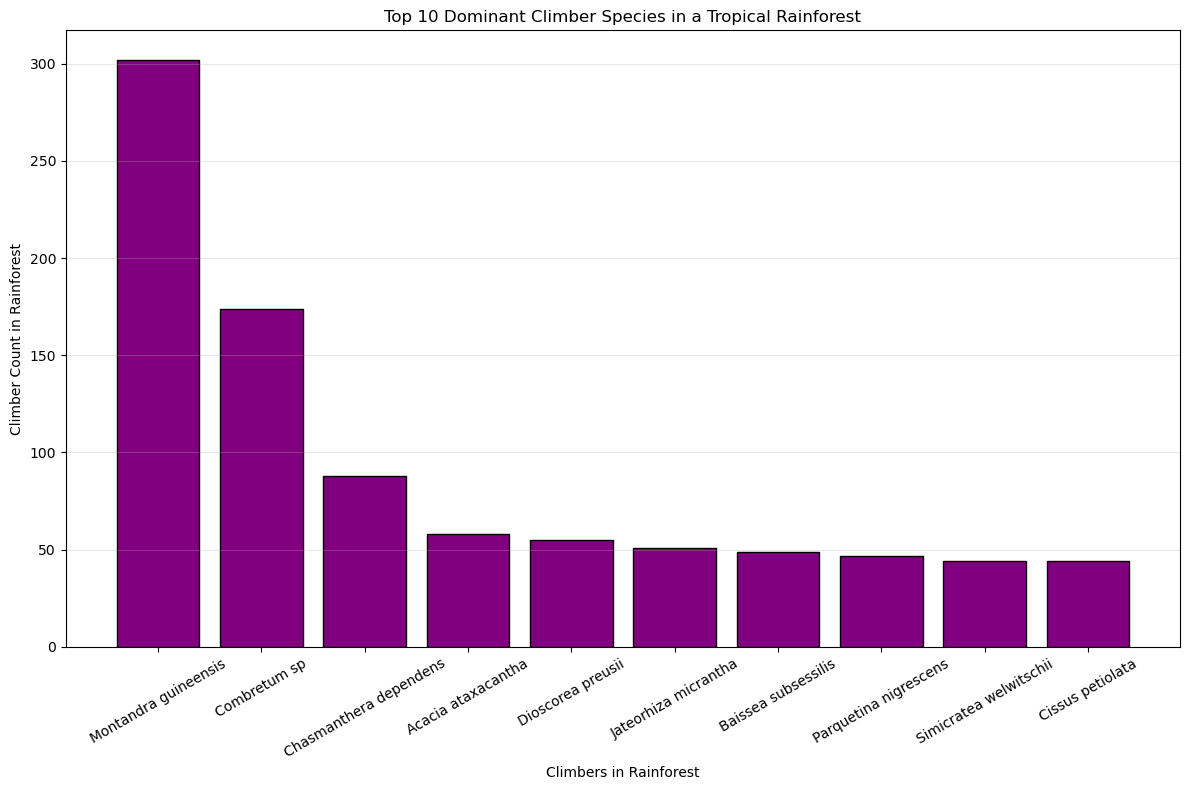

In [10]:
plt.figure(figsize = (12, 8))
plt.bar(top10_climbers.index, top10_climbers.values,
        color = 'purple', edgecolor = 'black')
plt.xlabel('Climbers in Rainforest')
plt.ylabel('Climber Count in Rainforest')
plt.title('Top 10 Dominant Climber Species in a Tropical Rainforest')
plt.xticks(rotation = 30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The bar chart revealed that the most dominant climber species in the tropical rainforest was Montandra guineensis. Out of the top ten dominant climber species in the forest, seven were woody climbers (lianas) viz Montandra guineensis, Combretum sp, Chasmanthera dependens, Acacia ataxacantha syn Senegalia ataxacantha, Baissea subsessilis, and Parquetina nigrescens syn Periploca nigrescens while three were herbaceous climbers (vines) viz Dioscorea preusii, Jateorhiza micrantha and Cissus petiolata

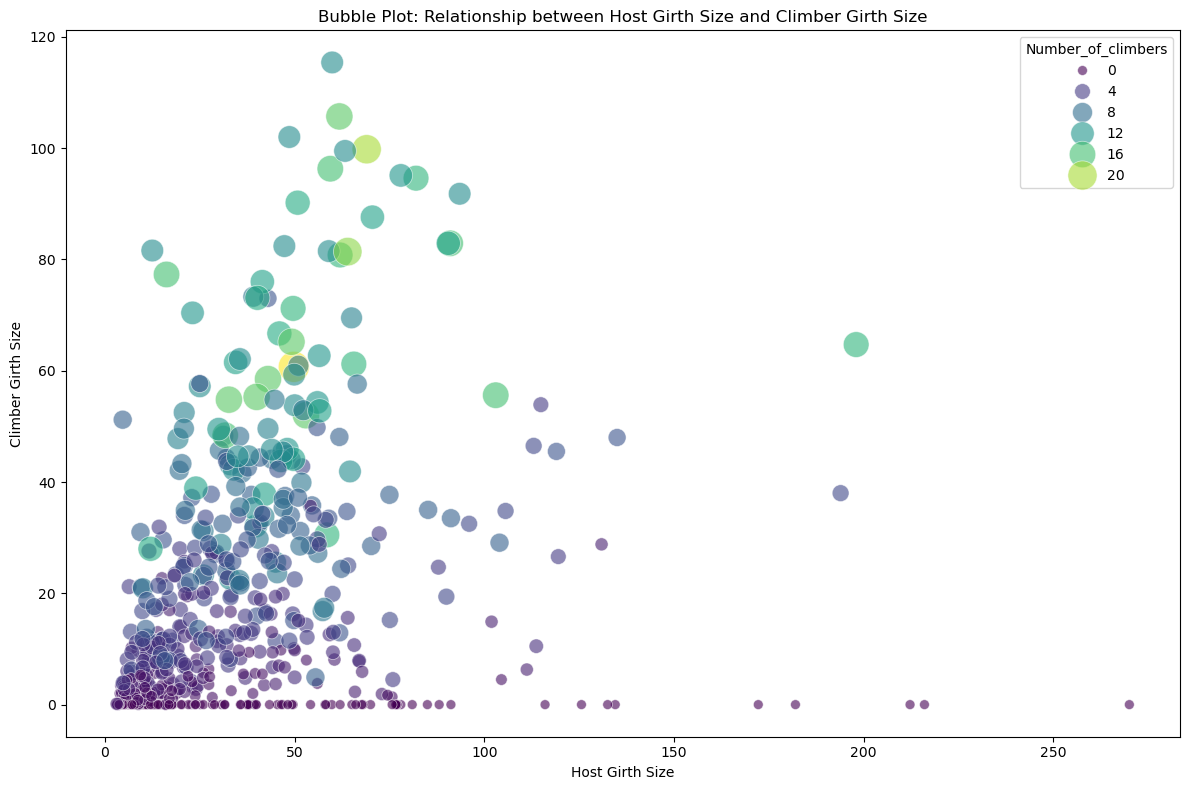

In [17]:
# Visualize the relationship between climber girth size (CGS) and host species girth size (HGS)
host_climber = data.dropna(subset = ['HGS', 'CGS', 'Number_of_climbers'])     #drop missing values in the columns we want to use
plt.figure(figsize=(12, 8))

sns.scatterplot(data = host_climber,               #visualizing a bubble plot with number of climbers on host as bubble size determinant
    x='HGS',
    y = 'CGS',
    size = 'Number_of_climbers',
    sizes = (50, 500),
    hue = 'Number_of_climbers',
    palette = "viridis",
    alpha = 0.6)

plt.title('Bubble Plot: Relationship between Host Girth Size and Climber Girth Size')
plt.xlabel('Host Girth Size')
plt.ylabel('Climber Girth Size')

plt.tight_layout()
plt.show()

In [21]:
# estimate the pearson correlation and probability value between host girth size and climber girth size
from scipy import stats
r, p_value = stats.pearsonr(data['CGS'], data['HGS'])
print('Pearson Correlation (r) is: ', r)
print('p-value is: ', p_value)

Pearson Correlation (r) is:  0.29893602100807726
p-value is:  1.2073615317652122e-13


The bubble plot showed that the relationship between host girth size and climber girth size was significantly positive but weak. Most notably, host species with medium-sized girth sizes hosted more number of climbers in the forest. This could be because these were the most abundant girth size category of host species in the forest.

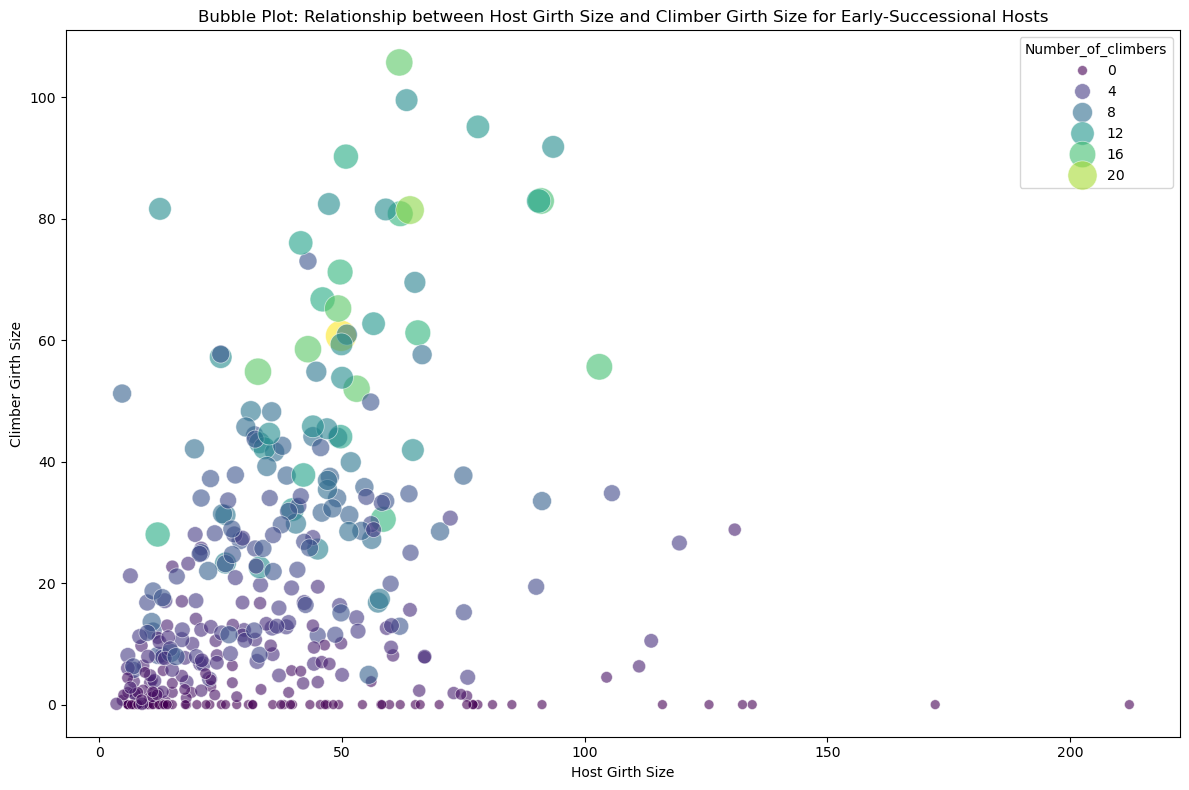

In [15]:
# Visualize relationship between early-successional host species girth size and corresponding climber girth size
data_early = data[data['Successional_status'] == 'early'].copy()
data_early = data_early.rename_axis('Host_ID').reset_index()



plt.figure(figsize=(12,8))

sns.scatterplot(data = data_early,               #visualizing a bubble plot with number of climbers on ES trees as bubble size determinant
    x='HGS',
    y = 'CGS',
    size = 'Number_of_climbers',
    sizes = (50, 500),
    hue = 'Number_of_climbers',
    palette = "viridis",
    alpha = 0.6)

plt.title('Bubble Plot: Relationship between Host Girth Size and Climber Girth Size for Early-Successional Hosts')
plt.xlabel('Host Girth Size')
plt.ylabel('Climber Girth Size')

plt.tight_layout()
plt.show()

In [20]:
# estimate the pearson correlation and probability value between early successional host girth size and climber girth size
from scipy import stats
r, p_value = stats.pearsonr(data_early['CGS'], data_early['HGS'])
print('Pearson Correlation (r) is: ', r)
print('p-value is: ', p_value)

Pearson Correlation (r) is:  0.24143980964787348
p-value is:  4.470671221630696e-06


The bubble plot showed that the relationship between early successional host girth size and corresponding climber girth size was significantly positive but weak. Most notably, host species with medium-sized girth sizes hosted more number of climbers in the forest, probably because these were the most abundant girth size category of host species in the forest.

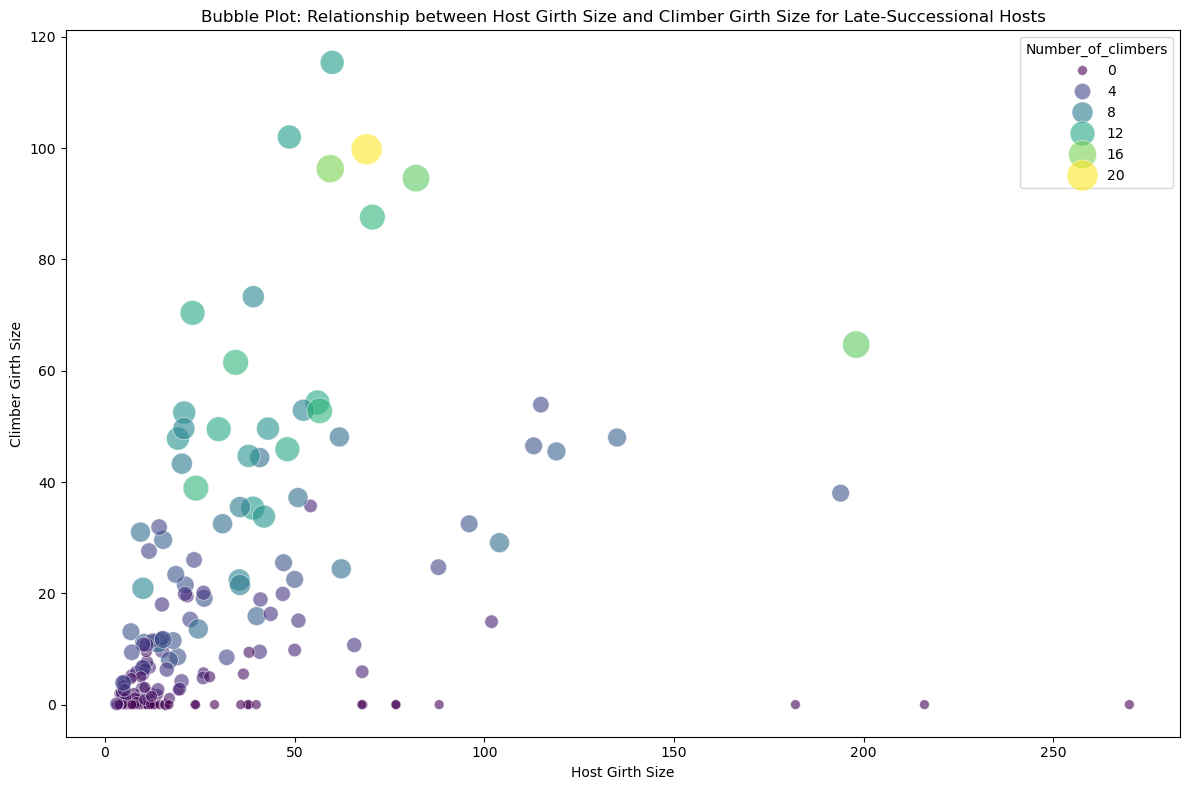

In [19]:
# Visualize relationship between late-successional host species girth size and corresponding climber girth size
data_late = data[data['Successional_status'] == 'late'].copy()
data_late = data_late.rename_axis('Host_ID').reset_index()



plt.figure(figsize=(12,8))

sns.scatterplot(data = data_late,               #visualizing a bubble plot with number of climbers on LS trees as bubble size determinant
    x='HGS',
    y = 'CGS',
    size = 'Number_of_climbers',
    sizes = (50, 500),
    hue = 'Number_of_climbers',
    palette = "viridis",
    alpha = 0.6)

plt.title('Bubble Plot: Relationship between Host Girth Size and Climber Girth Size for Late-Successional Hosts')
plt.xlabel('Host Girth Size')
plt.ylabel('Climber Girth Size')

plt.tight_layout()
plt.show()

In [22]:
# estimate the pearson correlation and probability value between late successional host girth size and climber girth size
from scipy import stats
r, p_value = stats.pearsonr(data_late['CGS'], data_late['HGS'])
print('Pearson Correlation (r) is: ', r)
print('p-value is: ', p_value)

Pearson Correlation (r) is:  0.34770689180096315
p-value is:  1.6185772241328648e-06


The bubble plot showed that the relationship between late successional host girth size and corresponding climber girth size was significantly positive but weak. Most notably, host species with medium-sized girth sizes hosted more number of climbers in the forest, probably because these were the most abundant girth size category of host species in the forest. It should be noted that some host species with big-sized girth sizes also hosted many climbers, although there was just a few of them in the forest.

In [28]:
# early_succ = data_early.drop(columns = ['Host_ID'])

print(data.select_dtypes(include=['number']).corr())
print(data_early.drop(columns = ['Host_ID']).select_dtypes(include=['number']).corr())
print(data_late.drop(columns = ['Host_ID']).select_dtypes(include=['number']).corr())

                    Number_of_climbers        BA       HGS       CGS
Number_of_climbers            1.000000  0.018087  0.222034  0.877111
BA                            0.018087  1.000000  0.713627  0.068226
HGS                           0.222034  0.713627  1.000000  0.298936
CGS                           0.877111  0.068226  0.298936  1.000000
                    Number_of_climbers        BA      HGS       CGS
Number_of_climbers            1.000000  0.004202  0.17971  0.867136
BA                            0.004202  1.000000  0.68506  0.071368
HGS                           0.179710  0.685060  1.00000  0.241440
CGS                           0.867136  0.071368  0.24144  1.000000
                    Number_of_climbers        BA       HGS       CGS
Number_of_climbers            1.000000  0.042083  0.254168  0.891124
BA                            0.042083  1.000000  0.774322  0.076830
HGS                           0.254168  0.774322  1.000000  0.347707
CGS                           0.891124 

In [45]:
# wrangle the top 15 host species that hosted the highest average number of climbers in the forest
top_host_group = (data.groupby('Host_species', as_index = False).agg({'Number_of_climbers':'mean'})
                  .sort_values('Number_of_climbers', ascending = False))
top15_host = top_host_group.head(15)
top15_host

,Host_species,Number_of_climbers
69,Strombosia pustulata,12.000000
49,Margaritaria discoides,11.000000
7,Blighia sp,11.000000
82,Zanthoxylum sp,11.000000
31,Ficus mucoso,8.928571
78,Triplochiton scleroxylon,8.666667
79,Trrichilia prieuriana,8.500000
8,Blighia unijugata,8.500000
70,Tabernaemontana moontana,8.000000
63,Pterocarpus sp,7.000000


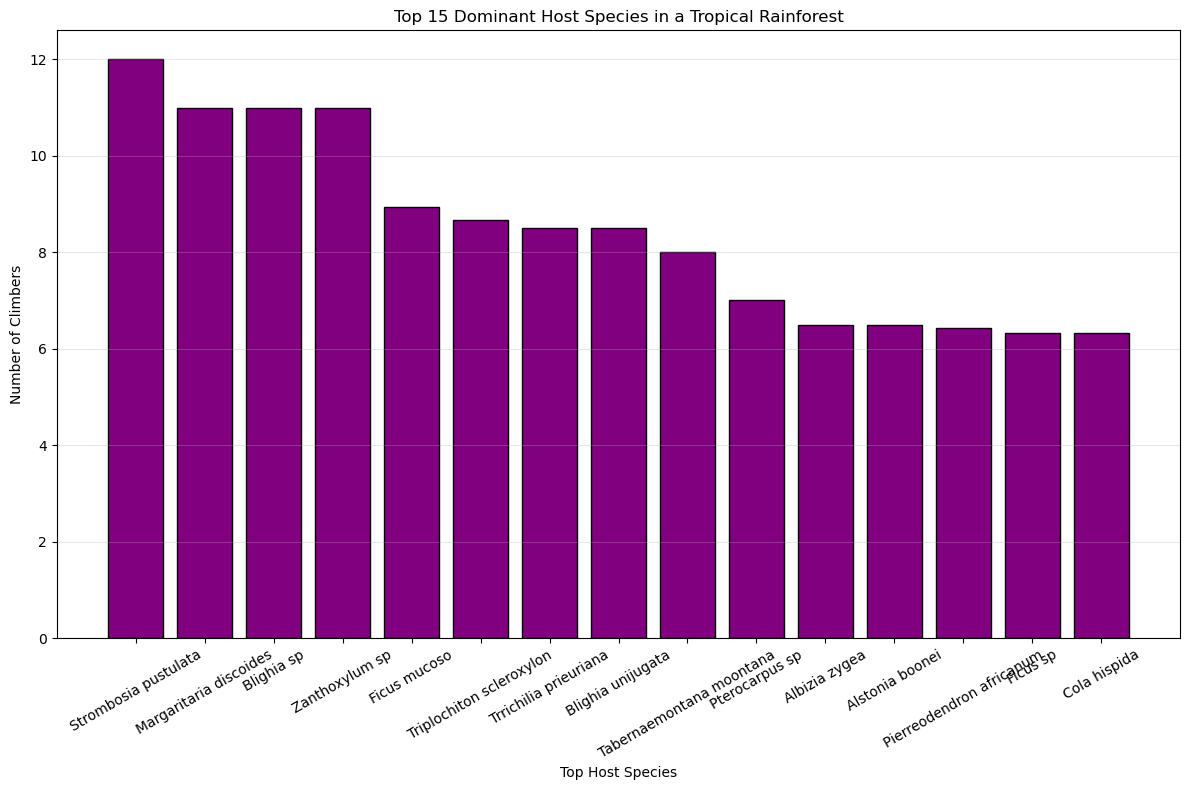

In [37]:
# visualize the top 15 host species that hosted the highest average number of climbers in the forest

plt.figure(figsize = (12, 8))
plt.bar(top15_host['Host_species'], top15_host['Number_of_climbers'], color = 'purple', edgecolor = 'black')
plt.xlabel('Top Host Species')
plt.ylabel('Number of Climbers')
plt.title('Top 15 Dominant Host Species in a Tropical Rainforest')
plt.xticks(rotation = 30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The bar plot revealed that a Strombosia pustulata hosted the highest average number of climbers in the forest. The visualization is a mixture of early- and late-successional host species.

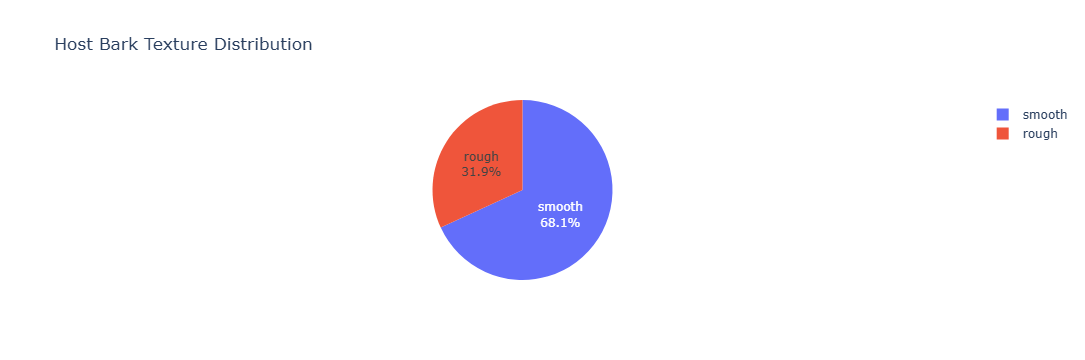

<Figure size 1000x700 with 0 Axes>

In [31]:
# visualize the percentages of bark texture categories in the forest

import plotly.express as px

barks = data['Bark_texture'].value_counts().reset_index()
barks.columns = ['texture', 'count']

plt.figure(figsize = (10, 7))
fig = px.pie(barks, names = 'texture', values = 'count', title = 'Host Bark Texture Distribution', color = 'texture')

fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

The pie chart showed that 68% of the host species in the forest had smooth barks, while 32% of the host species in the forest had rough barks.

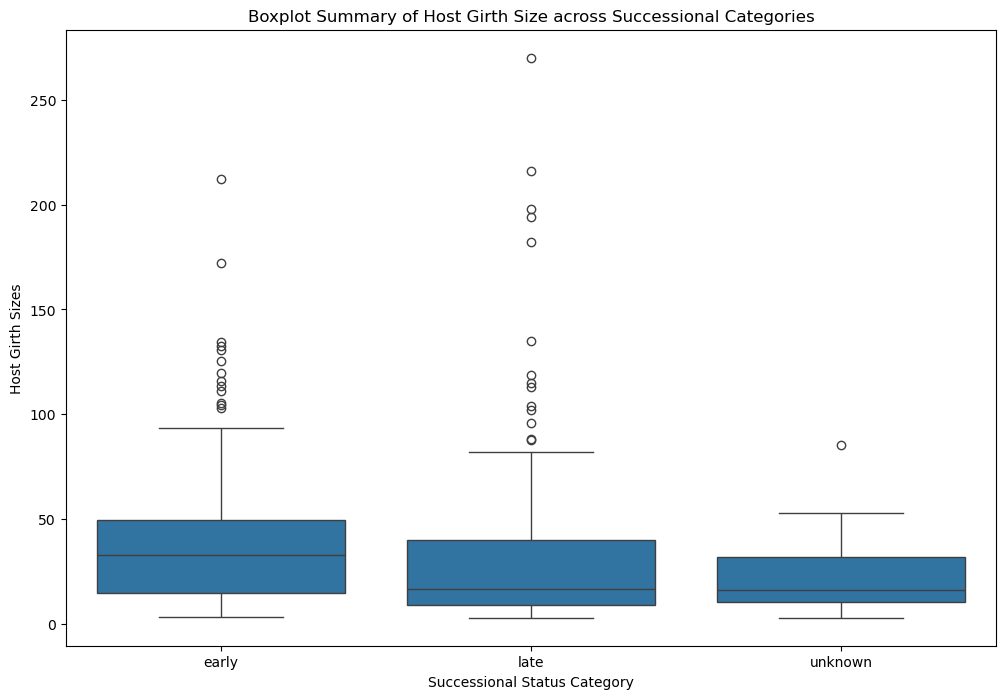

In [33]:
# visualize the girth sizes of host species in the successional_status categories

plt.figure(figsize = (12, 8))
sns.boxplot(x = 'Successional_status', y = 'HGS', data = data)

plt.title('Boxplot Summary of Host Girth Size across Successional Categories')
plt.xlabel('Successional Status Category')
plt.ylabel('Host Girth Sizes')
plt.show()

There was just one host species outlier with unknown successional status, while there were numerous outliers in the early- and late-successional categories. Since there were more early-successional host species in the forest, the median value was higher compared to those of the other two categories.

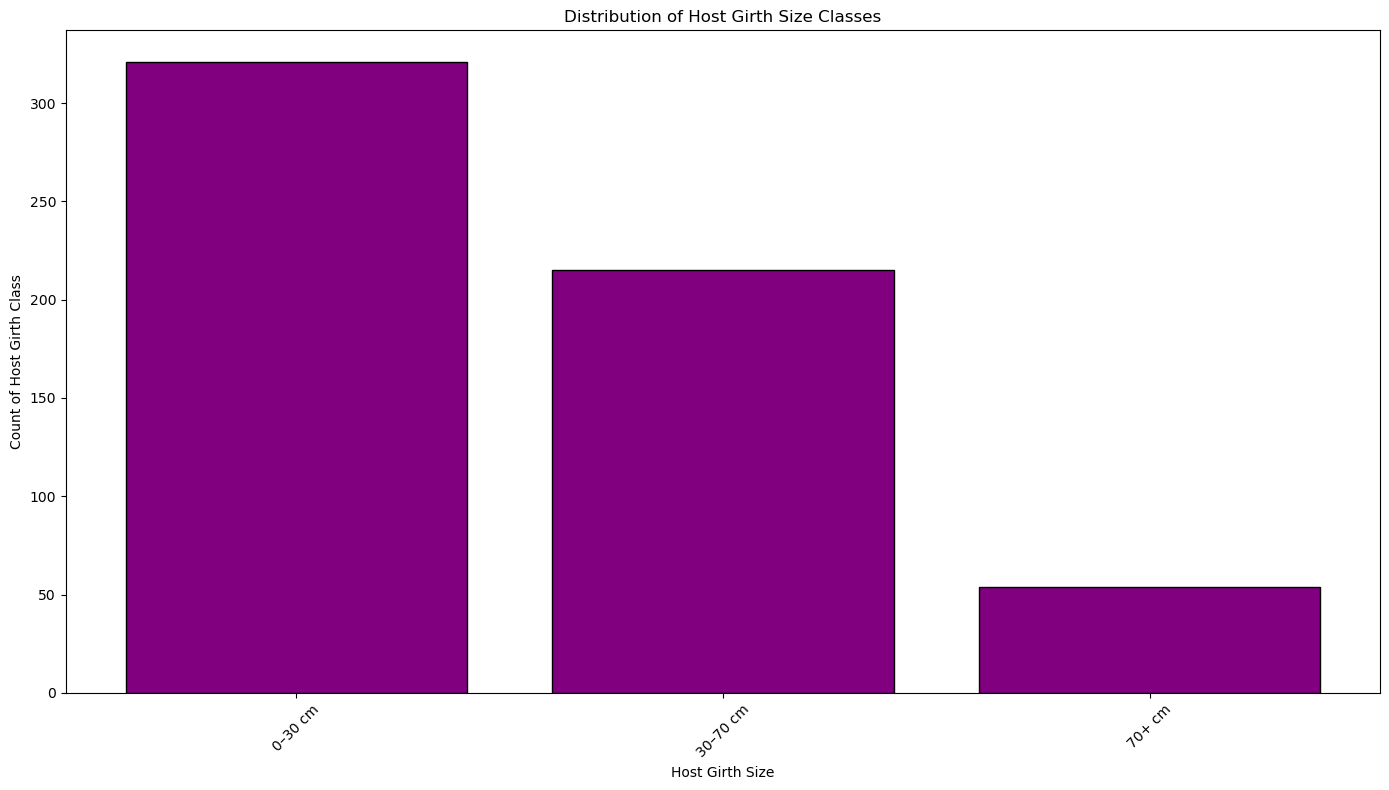

In [46]:
# Visualize the Host Girth Size Class Distribution

bins = [0, 30, 70, max(data['HGS'])]
labels = ["0–30 cm", "30–70 cm", "70+ cm"]

data['HGS_class'] = pd.cut(data['HGS'], bins=bins, labels=labels, include_lowest=True)

HGS_count = data['HGS_class'].value_counts().reindex(labels)
HGS_count.columns = ['binned', 'count']

plt.figure(figsize = (14, 8))
plt.bar(labels, HGS_count, color='purple', edgecolor='black')

plt.title('Distribution of Host Girth Size Classes')
plt.xlabel('Host Girth Size')
plt.ylabel('Count of Host Girth Class')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

The chart showed that the the host girth sizes were distributed into three classes, namely; 0-30 cm (small girth size class), 30-70 cm (medium girth size class) and 70+ cm (big girth size class). In the forest, more host species had small girth sizes while fewer host species were recorded to have had big girth sizes.

In [217]:
data['HGS_class'].value_counts()

HGS_class
0–30 cm     321
30–70 cm    215
70+ cm       54
Name: count, dtype: int64

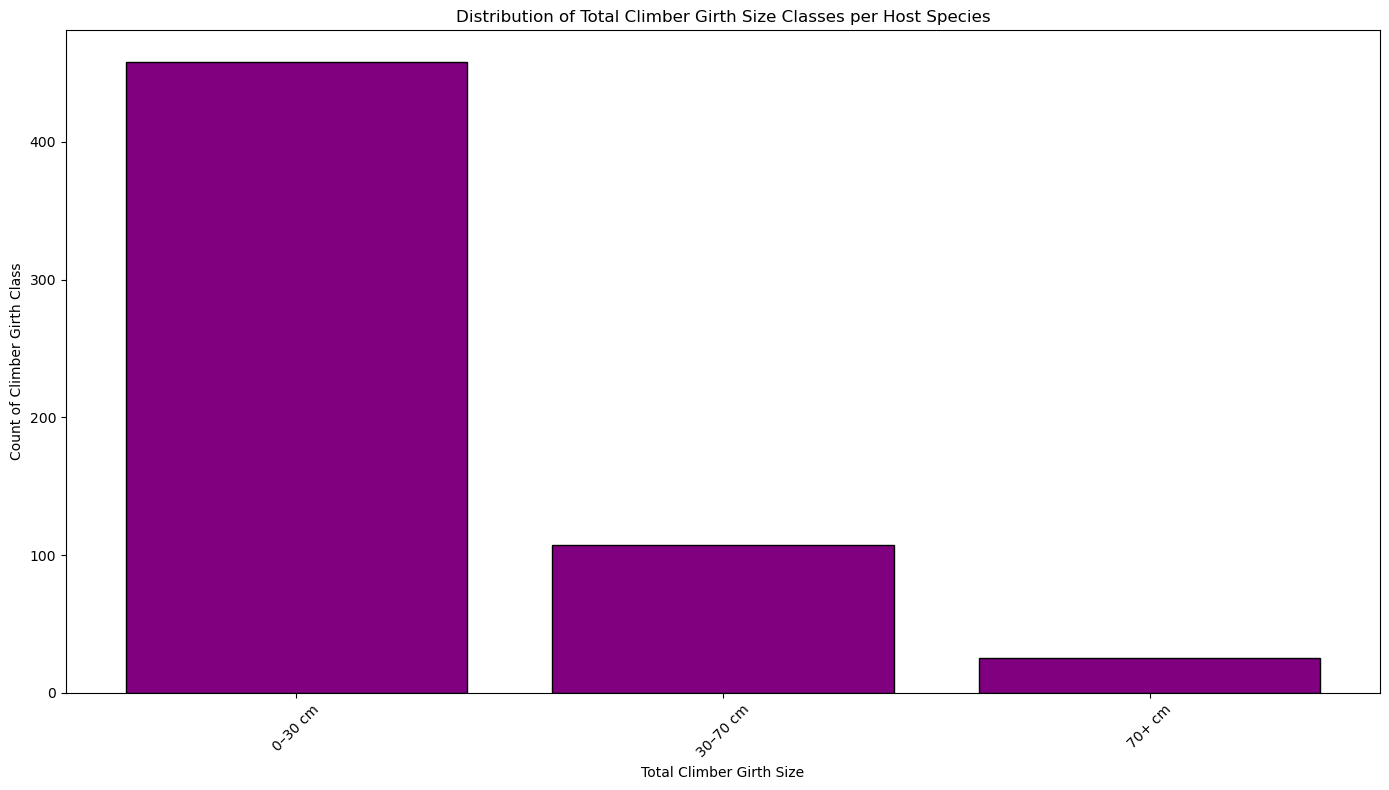

In [48]:
# Visualize the Girth Size Distribution of the Climber Species

bins = [0, 30, 70, max(data['CGS'])]
labels = ["0–30 cm", "30–70 cm", "70+ cm"]

data['CGS_class'] = pd.cut(data['CGS'], bins=bins, labels=labels, include_lowest=True)

CGS_count = data['CGS_class'].value_counts().reindex(labels)
CGS_count

plt.figure(figsize = (14, 8))
plt.bar(labels, CGS_count, color='purple', edgecolor='black')

plt.title('Distribution of Total Climber Girth Size Classes per Host Species')
plt.xlabel('Total Climber Girth Size')
plt.ylabel('Count of Climber Girth Class')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

First, it should be pointed out that each reading of the "CGS" (Climber Girth Size) column was derived as a summation of the girth sizes of every climber attached to a corresponding host tree species. For instance, the CGS of 4.8 recorded on row 2 of the data dataframe for Albizia zygea was the sum of the girth sizes of all three climbers attached to Albizia zygea. With that out of the way, the chart showed that the pattern of climber girth size distribution was similar to that of the host species, although the numbers attributed to each category differed compared to those of the host species girth size distribution.

In [50]:
# There was a bad entry in index 313 of the Climber_girth_size column. Correct it.
data.loc[313, 'Climber_girth_size'] = (str(data.loc[313, 'Climber_girth_size']).replace("0.102; 0,012; 0.056; 0.047; 0.106; 0.046; 0.224", "0.102; 0.012; 0.056; 0.047; 0.106; 0.046; 0.224"))

In [66]:
# wrangle out the individuals of the climber species
ind_CGS = data['Climber_girth_size'].str.split(";").explode().str.strip()
ind_CGS = pd.to_numeric(ind_CGS, errors='coerce')
ind_CGS_cm = ind_CGS * 100
ind_count = ind_CGS_cm.dropna().value_counts().reset_index()
ind_count.columns = ['cgs', 'count']
ind_count.head()

,cgs,count
0,0.6,33
1,1.2,32
2,2.0,30
3,0.4,30
4,4.5,27


In [67]:
bins = [0, 30, 60, ind_count['cgs'].max()+1]
labels = ['0–30 cm', '30–60 cm', '60+ cm']

ind_count['cgs_class'] = pd.cut(ind_count['cgs'], bins=bins, labels=labels, include_lowest=True)

cgs_count = ind_count['cgs_class'].value_counts().reindex(labels)
cgs_count

cgs_class
0–30 cm     231
30–60 cm     39
60+ cm        2
Name: count, dtype: int64

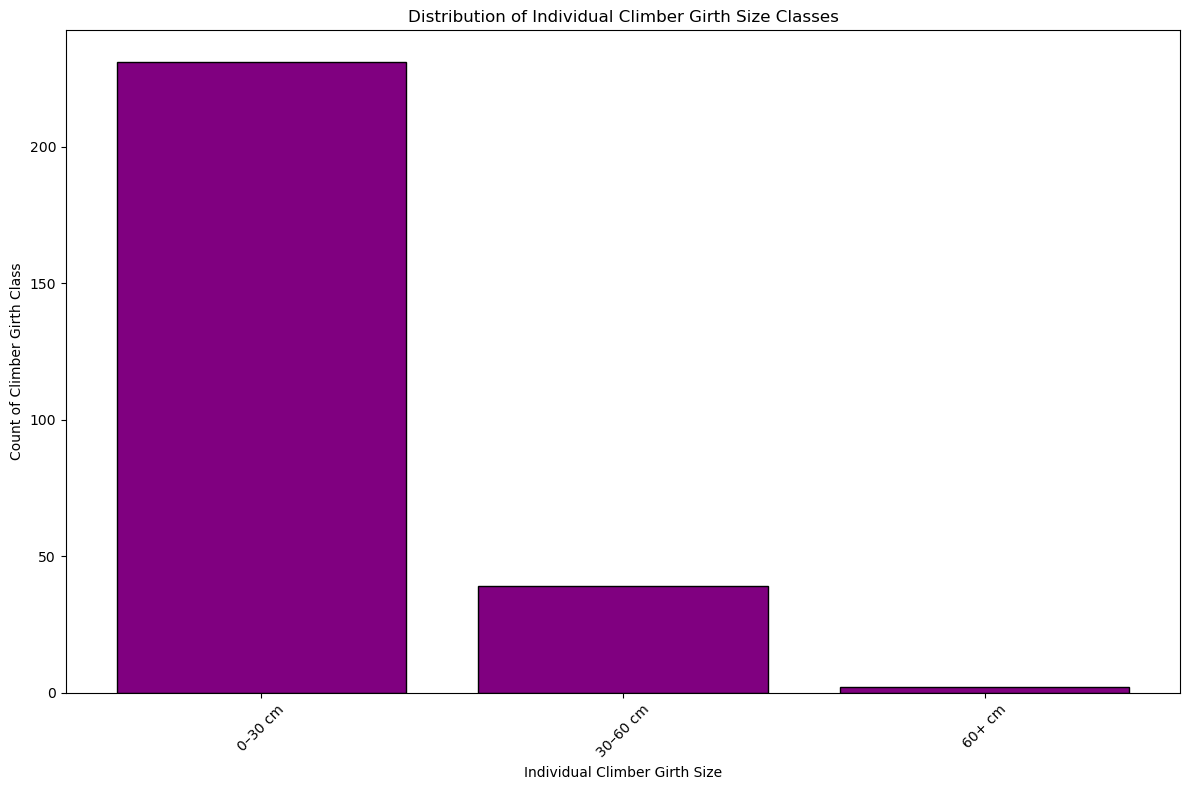

In [68]:
# visualize the distribution of individual girth sizes of climbers in the forest
plt.figure(figsize = (12, 8))
plt.bar(labels, cgs_count, color='purple', edgecolor='black')

plt.title('Distribution of Individual Climber Girth Size Classes')
plt.xlabel('Individual Climber Girth Size')
plt.ylabel('Count of Climber Girth Class')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

As expected, most of the climber individuals in the forest had small girth sizes.

In [75]:
climb_gs = pd.DataFrame({'climber': climber_series.reset_index(drop=True),'cgs_cm': ind_CGS_cm.reset_index(drop=True)})
climb_gs.shape

(1515, 2)

In [78]:
climb_gs = climb_gs.dropna()

In [81]:
climb_gs.head()

,climber,cgs_cm
1,Cissus petiolata,2.0
2,Ampelocissus bombycina,1.5
3,Chasmanthera dependens,1.3
4,Cissus petiolata,8.1
5,Combretum sp,6.7


In [82]:
# Visualize the top 15 Individuals of Climber Species with the Highest Average Girth Sizes
climber_group = climb_gs.groupby('climber')['cgs_cm'].mean()
climber_sort = climber_group.sort_values(ascending = False)
top15_sorted = climber_sort.head(15)
top15_sorted

climber
Abrus precatorius        30.500000
Centrosema pubescens     17.100000
Sabicia sp               13.300000
Chlamydocarya sp         12.522222
Cissus arguta            12.485714
Dioscorea sp             11.800000
Landolphia dulcis        10.766667
Oncinotis gracilis        9.853846
Grewia carponifolia       9.812500
Dioscorea preusii         9.117647
Smilax kraussiana         8.897059
Cnestis ferruginea        8.720000
Parquetina nigrescens     8.524390
Dalbergia lactea          8.476923
Combretum racemosum       8.284615
Name: cgs_cm, dtype: float64

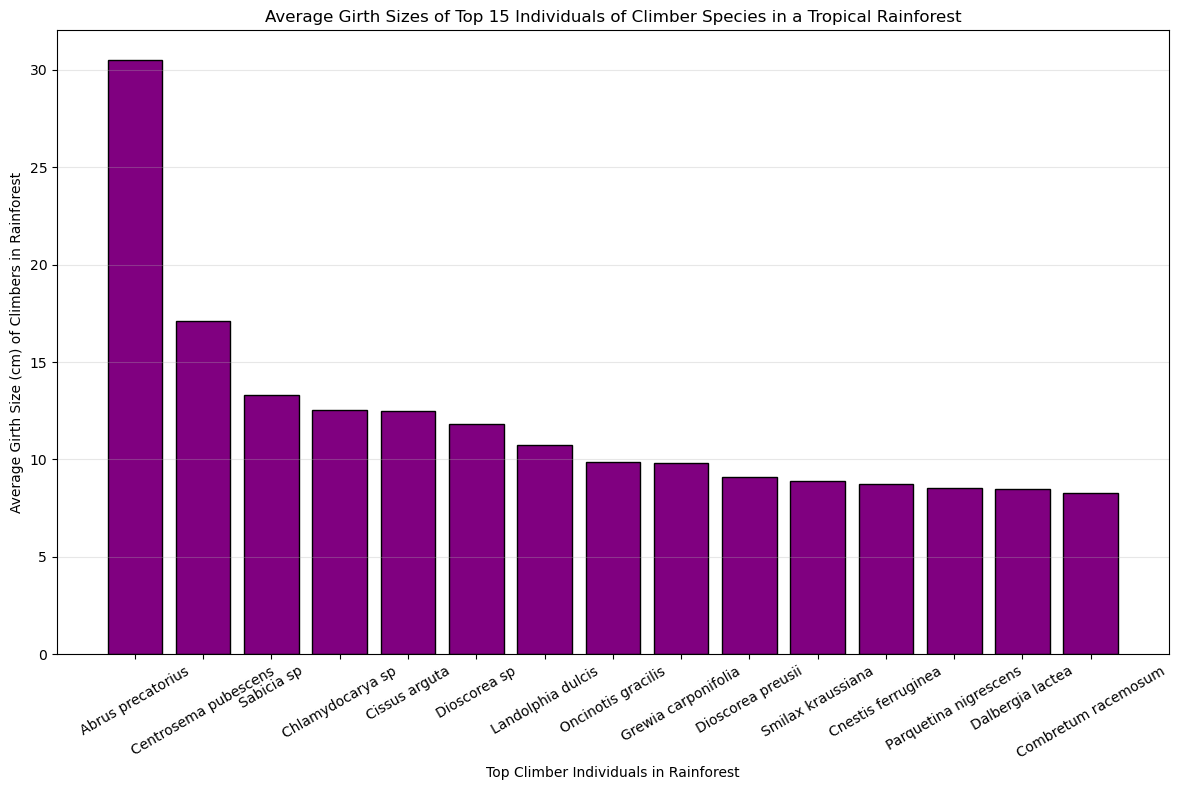

In [83]:
plt.figure(figsize = (12, 8))
plt.bar(top15_sorted.index, top15_sorted.values,
        color = 'purple', edgecolor = 'black')
plt.xlabel('Top Climber Individuals in Rainforest')
plt.ylabel('Average Girth Size (cm) of Climbers in Rainforest')
plt.title('Average Girth Sizes of Top 15 Individuals of Climber Species in a Tropical Rainforest')
plt.xticks(rotation = 30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The bar chart showed that Abrus precatorius had the highest average girth size in the forest. This is likely because it, alongside many of the top 15 climber species had less occurrences in the forest, on a plot by plot basis. This was why many of these species were not listed among the top climbers (frequency of occurrence) in the forest.

Text(0.5, 9.444444444444438, 'Climber Girth Size (cm)')

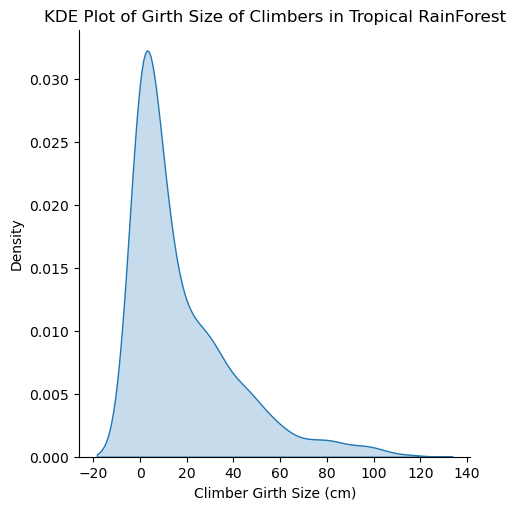

In [86]:
# Visualize the frequency distribution of the climbers in the forest

sns.displot(data['CGS'], kind="kde", fill=True)
plt.title('KDE Plot of Girth Size of Climbers in Tropical RainForest')
plt.xlabel('Climber Girth Size (cm)')

The KDE distribution of climber girth sizes shows a high concentration of individuals in the smaller size classes, with density declining toward larger diameters. This right‑skewed pattern indicates that the climber community is dominated by small to medium‑sized climbers, with relatively few large‑diameter individuals. This distribution is typical of tropical rainforest climber community assemblages, where many species remain thin while only a handful achieve substantial girth.

In [88]:
data = data.reset_index().rename(columns={'index': 'Host_ID'})
data.head()

,Host_ID,climber_status,Plot,Host_species,Number_of_climbers,BA,HGS,CGS,Bark_texture,Successional_status,Climber,Climber_girth_size,HGS_class,CGS_class
0,0,absent,I,Albizia sp,0,0.4283,116.005112,0.0,smooth,early,None,0,70+ cm,0–30 cm
1,1,present,I,Albizia zygea,3,0.0436,37.012322,4.8,smooth,early,Chasmanthera dependens; Cissus petiolata; Ampe...,0.02; 0.015; 0.013,30–70 cm,0–30 cm
2,2,present,I,Albizia zygea,17,0.0894,52.999509,52.0,smooth,early,Chasmanthera dependens; Cissus petiolata; Comb...,0.081; 0.067; 0.142; 0.16; 0.07,30–70 cm,30–70 cm
3,3,present,I,Albizia zygea,10,0.0215,25.990960,23.3,smooth,early,Chasmanthera dependens; Cissus gracilis; Combr...,0.018; 0.009; 0.013; 0.04; 0.013; 0.05; 0.06; ...,0–30 cm,0–30 cm
4,4,present,I,Albizia zygea,4,0.0058,13.499481,17.1,smooth,early,Combretum sp,0.171,0–30 cm,0–30 cm


In [90]:
# Visualize a Scatter Plot showing the Binary Dependent Variable and Numeric Independent Variable
data['climber_status_bin'] = (data['climber_status'] == 'present').astype(int)      #converts the string label into numerical category

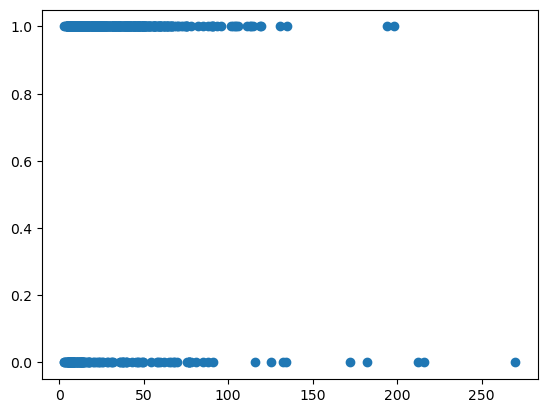

In [91]:
plt.scatter(x=data['HGS'], y=data['climber_status_bin'])

The plot showed that host species with higher girth sizes seemed to have fewer climber infestation. This means that as girth size increased, climber infestation decreased.

<Axes: xlabel='climber_status_bin', ylabel='count'>

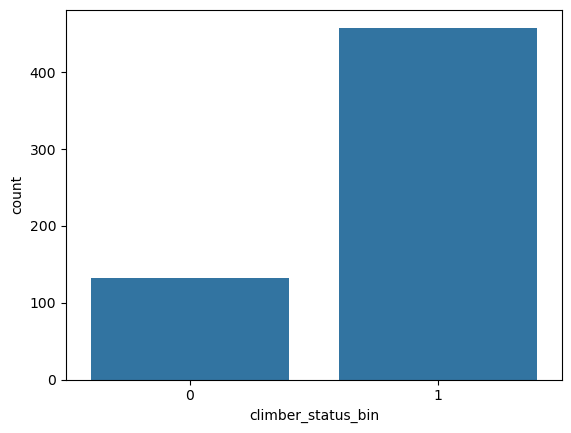

In [92]:
# Visualize the Climber Counts per Climber Status Category
sns.countplot(x='climber_status_bin', data=data)

This plot showed that the dataset had more climber presence than absence on host species in the tropical forest

### Using the HGS variable as predictor, we will see if it is enough to predict the climber infestation in the forest

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X = data[['HGS']]
y = data['climber_status_bin']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify = y)

In [98]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

LogisticRegression()

In [99]:
y_pred = log_model.predict(X_test)

In [100]:
log_model.score(X_test, y_test)

0.7740112994350282

In [101]:
# Run the confusion matrix for this model
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[  0  40]
 [  0 137]]


In [102]:
print(classification_report(y_test, y_pred))

C:\Users\Nelson\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\Nelson\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\Nelson\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



              precision    recall  f1-score   support

           0       0.00      0.00      0.00        40
           1       0.77      1.00      0.87       137

    accuracy                           0.77       177
   macro avg       0.39      0.50      0.44       177
weighted avg       0.60      0.77      0.68       177



The confusion matrix and classification report show that the Host Girth Size was not adequate to predict the climber infestation in the forest. However, we could include some sort of ridge penalty to reduce overfitting and to create a balance in the model so that the model would not always predict absence of climbers

In [103]:
log_model2 = LogisticRegression(penalty = 'l2', solver = 'lbfgs', max_iter = 500, class_weight = 'balanced')

log_model2.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=500)

In [104]:
y1_pred = log_model2.predict(X_test)

In [105]:
log_model2.score(X_test, y_test)

0.5423728813559322

In [106]:
print(confusion_matrix(y_test, y_pred))

[[  0  40]
 [  0 137]]


#### Since the numeric HGS predictor variable is not adequate to predict climber colonization in the forest, it would be perfect to use multiple features. First we start by converting the HGS feature to a category variable. This eliminates the need to scale the features.

In [107]:
bins = [0, 30, 70, float('inf')]
labels = ['small', 'medium', 'big']

data['HGS_cat'] = pd.cut(data['HGS'], bins=bins, labels=labels, include_lowest=True)

In [111]:
# Binary Logistic Regression Modeling

import statsmodels.formula.api as smf

# Select the features to use as predictors

model_traits = smf.logit(formula = "climber_status_bin ~ C(HGS_cat) + C(Bark_texture) + C(Successional_status)", data=data).fit()

print(model_traits.summary())

Optimization terminated successfully.
         Current function value: 0.513150
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:     climber_status_bin   No. Observations:                  590
Model:                          Logit   Df Residuals:                      584
Method:                           MLE   Df Model:                            5
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                 0.03468
Time:                        17:26:03   Log-Likelihood:                -302.76
converged:                       True   LL-Null:                       -313.64
Covariance Type:            nonrobust   LLR p-value:                 0.0005825
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Intercept                             1.1783      0.236      4

This logistic regressionmodel showed a well-converged model that converged quickly after just 6 iterations. The low value of current function value is an indication that the model is a statistically good one. The number of features were 5 viz (HGS_cat)[T.medium], (HGS_cat)[T.big], (Bark_texture)[T.smooth], (Successional_status)[T.late] and (Successional_status)[T.unknown].
The Pseudo R-square value in the model showed that the features had a very small effect in predicting the colonization of climbers in the forest. The features only explain a small but quite meaningful amount of variation in climber colonization. However, it must be stated that the features significantly improved the model’s ability to predict climber colonization as evidenced in the significant log-likelihood ratio. Thus, even though pseudo‑R-square value is small, the improvement in the model is statistically meaningful.
It is, therefore, recommended that future predictions should include features such as canopy structure, crown and biomass of host species, habitat types, etc, to better predict climber colonization in the forest.

### Estimate the Odds Ratio, Z-score, and Coefficient of the Logistic Model in a Table

In [113]:
# Coefficients table
coef_table = pd.DataFrame({"coef": model_traits.params, "std_err": model_traits.bse, "z": model_traits.tvalues, "p_value": model_traits.pvalues})

# Add odds ratios and 95% CI
coef_table["odds_ratio"] = np.exp(coef_table["coef"])
coef_table["OR_lower"] = np.exp(coef_table["coef"] - 1.96 * coef_table["std_err"])
coef_table["OR_upper"] = np.exp(coef_table["coef"] + 1.96 * coef_table["std_err"])

coef_table


,coef,std_err,z,p_value,odds_ratio,OR_lower,OR_upper
Intercept,1.178282,0.236058,4.991502,5.991150e-07,3.248787,2.045432,5.160091
C(HGS_cat)[T.medium],0.823358,0.243999,3.374435,7.396746e-04,2.278136,1.412160,3.675153
C(HGS_cat)[T.big],-0.524566,0.313287,-1.674392,9.405358e-02,0.591812,0.320264,1.093603
C(Bark_texture)[T.smooth],-0.087465,0.219846,-0.397848,6.907421e-01,0.916251,0.595494,1.409779
C(Successional_status)[T.late],-0.210281,0.222832,-0.943675,3.453356e-01,0.810356,0.523597,1.254165
C(Successional_status)[T.unknown],0.013940,0.359559,0.038769,9.690750e-01,1.014037,0.501177,2.051712


The table showed that none of the features would increase the probability of climber colonization since the they all had coefficients less than 1. The closest predictor, however, was the host species with medium girth sizes. It should be stated that with an odds ratio value greater than 1, host species with medium girth sizes had higher tendencies to predict climber colonization. This effect is highly statistically significant.

In [115]:
# X is the design matrix used to fit the model
data["prob_climber"] = model_traits.predict(data)

In [127]:
top_prob_data = data.sort_values('prob_climber', ascending = False).tail(10)
top_prob_data

,Host_ID,climber_status,Plot,Host_species,Number_of_climbers,BA,HGS,CGS,Bark_texture,Successional_status,Climber,Climber_girth_size,HGS_class,CGS_class,climber_status_bin,HGS_cat,prob_climber
395,395,present,II,Ricinodendron heudelotii,2,0.330500,101.903435,14.9,smooth,late,Ampelocissus bombycina; Dioscorea preusii,0.11; 0.039,70+ cm,0–30 cm,1,big,0.588064
447,447,present,III,Ricinodendron heudelotii,15,4.999000,198.000802,64.7,smooth,late,Baissea subsessilis; Cissus adenopoda; Cissus ...,0.006; 0.006; 0.015; 0.160; 0.010; 0.357; 0.01...,70+ cm,30–70 cm,1,big,0.588064
448,448,present,III,Ricinodendron heudelotii,7,1.379200,104.001357,29.1,smooth,late,Cissus adenopoda; Combretum sp; Montandra guin...,0.006; 0.045; 0.02; 0.18; 0.04,70+ cm,0–30 cm,1,big,0.588064
502,502,present,IV,Ricinodendron heudelotii,4,1.756600,114.900023,53.9,smooth,late,Combretum sp; Montandra guineensis,0.188; 0.351,70+ cm,30–70 cm,1,big,0.588064
546,546,absent,VI,Celtis mildbraedii,0,0.988111,88.100000,0.0,smooth,late,None,0,70+ cm,0–30 cm,0,big,0.588064
236,236,present,I,Tetrapleura tetraptera,13,0.158200,70.502794,87.6,smooth,late,Chasmanthera dependens; Cissus petiolata; Dalb...,0.078; 0.079; 0.037; 0.154; 0.153; 0.217; 0.158,70+ cm,70+ cm,1,big,0.588064
235,235,present,I,Tetrapleura tetraptera,5,0.293300,95.997323,32.5,smooth,late,Acacia ataxacantha; Cissus petiolata; Parqueti...,0.188; 0.099; 0.038,70+ cm,30–70 cm,1,big,0.588064
234,234,present,I,Tetrapleura tetraptera,6,0.580000,134.994815,48.0,smooth,late,Combretum sp; Montandra guineensis; Parquetina...,0.052; 0.123; 0.305,70+ cm,30–70 cm,1,big,0.588064
233,233,present,I,Tetrapleura tetraptera,6,0.450700,118.999975,45.5,smooth,late,Acacia ataxacantha; Chasmanthera dependens; Co...,0.367; 0.02; 0.06; 0.008,70+ cm,30–70 cm,1,big,0.588064
588,588,absent,VI,Ricinodendron heudelotii,0,9.280713,270.000000,0.0,smooth,late,None,0,70+ cm,0–30 cm,0,big,0.588064


Given the features used in building this model, the probabilities of climber colonization of host species ranged from medium to high. Specifically, rough-barked host species with medium-sized girths had higher probabilities of colonization, while smooth-barked host species with big girth sizes had moderate probabilities of colonization in the forest. However, given the high prevalence of climbers in the forest, the features used in building the model could not strongly discriminate colonized from uncolonized hosts, even though it influenced the colonization probabilities.

In [128]:
# Streamlining the Host Species to the Most Frequent Host Species to Reduce Redundancy

host_counts = data["Host_species"].value_counts()
rare_hosts = host_counts[host_counts < 5].index

data["Host_species_collapsed"] = data["Host_species"].replace(rare_hosts, "Other_host")

In [138]:
formula = """
climber_status_bin ~ 
    C(HGS_cat) +
    C(Bark_texture) +
    C(Successional_status) +
    C(Plot) +
    C(Host_species_collapsed)
"""

full_model = smf.logit(formula=formula, data=data).fit_regularized(method="l1")

full_model.summary()

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.46104588263001806
            Iterations: 302
            Function evaluations: 302
            Gradient evaluations: 302


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:     climber_status_bin   No. Observations:                  590
Model:                          Logit   Df Residuals:                      545
Method:                           MLE   Df Model:                           44
Date:                Mon, 06 Apr 2026   Pseudo R-squ.:                  0.1327
Time:                        19:12:52   Log-Likelihood:                -272.02
converged:                       True   LL-Null:                       -313.64
Covariance Type:            nonrobust   LLR p-value:                 0.0003228
============================================================================================================================
                                                               coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------------
Intercept                                                    1.3417      1.211      1.108      0.268      -1.033       3.716
C(HGS_cat)[T.medium]                                         0.6404      0.293      2.185      0.029       0.066       1.215
C(HGS_cat)[T.big]                                           -0.8904      0.388     -2.292      0.022      -1.652      -0.129
C(Bark_texture)[T.smooth]                                    0.5900      0.558      1.057      0.291      -0.504       1.684
C(Successional_status)[T.late]                              -0.4263      0.652     -0.654      0.513      -1.705       0.852
C(Successional_status)[T.unknown]                            0.3783      0.781      0.484      0.628      -1.152       1.909
C(Plot)[T.II]                                               -0.3411      0.327     -1.044      0.296      -0.981       0.299
C(Plot)[T.III]                                               0.7059      0.525      1.343      0.179      -0.324       1.736
C(Plot)[T.IV]                                                0.3063      0.429      0.714      0.475      -0.534       1.147
C(Plot)[T.V]                                                -0.2263      0.651     -0.348      0.728      -1.501       1.049
C(Plot)[T.VI]                                               -1.2600      0.496     -2.540      0.011      -2.232      -0.288
C(Host_species_collapsed)[T.Alstonia boonei]                -0.0956      1.653     -0.058      0.954      -3.335       3.144
C(Host_species_collapsed)[T.Baphia nitida]                   0.7342      1.663      0.441      0.659      -2.526       3.994
C(Host_species_collapsed)[T.Blighia sapida]                 -0.8394      1.212     -0.692      0.489      -3.216       1.537
C(Host_species_collapsed)[T.Bombax buonopozense]            -1.2873      1.549     -0.831      0.406      -4.323       1.749
C(Host_species_collapsed)[T.Carpolobia lutea]               -4.0351      1.747     -2.310      0.021      -7.459      -0.611
C(Host_species_collapsed)[T.Celtis mildbraedii]              1.1002      1.699      0.647      0.517      -2.230       4.431
C(Host_species_collapsed)[T.Celtis zenkeri]                  0.5139      1.248      0.412      0.681      -1.932       2.960
C(Host_species_collapsed)[T.Cola millenii]                   0.4600      1.600      0.287      0.774      -2.676       3.596
C(Host_species_collapsed)[T.Dracaena manii]                 -0.6972      1.485     -0.469      0.639      -3.609       2.214
C(Host_species_collapsed)[T.Ficus exasperata]                0.0561      1.513      0.037      0.970      -2.910       3.022
C(Host_species_collapsed)[T.Ficus mucoso]                   -0.6640      1.320     -0.503      0.615      -3.252       1.924
C(Host_species_collapsed)[T.Funtumia africana]              13.3289    802.873      0.017      0.987   -1560.274    

This model showed that there were just a few significant predictors of climber colonization. This was very much evidenced in the significant effect of the medium girth size of host species as predictor for climber colonization while large host species were unlikely to be colonized by climbers. Furthermore, the model revealed a site-specific colonization of climbers since plot VI was the least likely of the six study plots to be colonized by climbers in the forest. In addition, of all the host species, Carpolobia lutea was the least likely to be colonized by climbers in the forest.
Because of their scanty representation in the forest, some host species had ridiculously high coefficients. This does not translate to any form of colonization, they are just not well represented in the forest to be enough to predict colonization of climbers.

In [139]:
# Extract coefficients and produce an odds ratio table
params = full_model.params
conf = full_model.conf_int()
conf.columns = ["2.5%", "97.5%"]

# Build OR table
or_table = pd.DataFrame({
    "coef": params,
    "odds_ratio": np.exp(params),
    "OR_2.5%": np.exp(conf["2.5%"]),
    "OR_97.5%": np.exp(conf["97.5%"]),
    "p_value": full_model.pvalues
})

or_table


C:\Users\Nelson\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning:

overflow encountered in exp



,coef,odds_ratio,OR_2.5%,OR_97.5%,p_value
Intercept,1.341711,3.825583e+00,0.356065,41.102262,0.268058
C(HGS_cat)[T.medium],0.640351,1.897146e+00,1.068208,3.369347,0.028880
C(HGS_cat)[T.big],-0.890359,4.105085e-01,0.191706,0.879039,0.021916
C(Bark_texture)[T.smooth],0.589975,1.803943e+00,0.603917,5.388506,0.290653
C(Successional_status)[T.late],-0.426347,6.528895e-01,0.181773,2.345035,0.513419
C(Successional_status)[T.unknown],0.378314,1.459821e+00,0.315855,6.747012,0.628116
C(Plot)[T.II],-0.341072,7.110076e-01,0.374872,1.348543,0.296321
C(Plot)[T.III],0.705916,2.025701e+00,0.723291,5.673320,0.179125
C(Plot)[T.IV],0.306309,1.358402e+00,0.586137,3.148168,0.475058
C(Plot)[T.V],-0.226344,7.974434e-01,0.222838,2.853716,0.727876


Therefore, it is safe to say that host species did not quite predict climber colonization in the forest. It is probably best to remove them from the model.

#### Before I go any further, let's try and train the model with more features. Earlier, Host Girth Size was not adequate. Now we will include more features in the training dataset

In [148]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Features and target
X1 = data[['Host_species', 'Bark_texture', 'Successional_status', 'HGS_cat']]
y1 = data['climber_status_bin']

# Identify categorical columns
categorical_cols = ['Host_species', 'Bark_texture', 'Successional_status', 'HGS_cat']

# Preprocessor: one-hot encode categorical variables
preprocess = ColumnTransformer(transformers = [('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)])

# Build pipeline: preprocessing + logistic regression
reg_model = Pipeline(steps = [('preprocess', preprocess),('logreg', LogisticRegression(max_iter = 500, class_weight = 'balanced'))])

# Train-test split
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size = 0.3, random_state = 42)

In [149]:
# Fit the model
reg_model.fit(X_train1, y_train1)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Host_species',
                                                   'Bark_texture',
                                                   'Successional_status',
                                                   'HGS_cat'])])),
                ('logreg',
                 LogisticRegression(class_weight='balanced', max_iter=500))])

In [150]:
y_pred1 = reg_model.predict(X_test1)

In [151]:
reg_model.score(X_test1, y_test1)

0.5819209039548022

In [152]:
cm = confusion_matrix(y_test1, y_pred1)
print(cm)
print(classification_report(y_test1, y_pred1))

[[21 14]
 [60 82]]
              precision    recall  f1-score   support

           0       0.26      0.60      0.36        35
           1       0.85      0.58      0.69       142

    accuracy                           0.58       177
   macro avg       0.56      0.59      0.53       177
weighted avg       0.74      0.58      0.62       177



<Axes: >

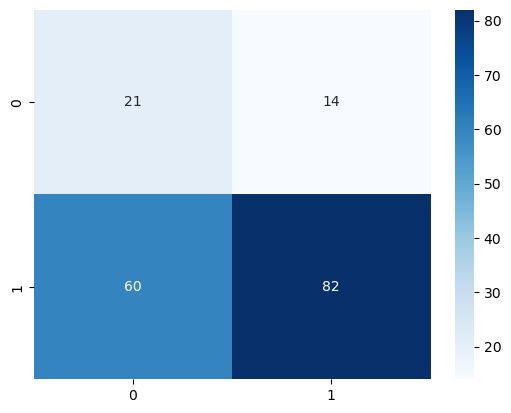

In [153]:
# Visualize the confusion matrix in a heatmap
sns.heatmap(cm, annot=True, fmt = 'd', cmap = 'Blues')

The confusion matrix revealed that the model correctly identified 82 climber-infested host species, incorrectly labelled 14 host species that were not infested by climbers as being climber-infested, incorrectly labelled 60 host species that were infested by climbers as being not climber-infested and correctly identified 21 host species as being not climber infested.
Precision is high (0.85), meaning that predicted presences are usually correct. However, the model still misses a substantial number of climber‑present trees (60 false negatives), indicating that additional features may be needed.

In essence, it can be seen that more features improved the integrity of the logistic regression model

#### Earlier, I examined the combined presence/absence of all climbers cumulatively. Now let's examine the logistic regression model of the top 10 climber species in the forest.

In [154]:
data.head()

,Host_ID,climber_status,Plot,Host_species,Number_of_climbers,BA,HGS,CGS,Bark_texture,Successional_status,Climber,Climber_girth_size,HGS_class,CGS_class,climber_status_bin,HGS_cat,prob_climber,Host_species_collapsed
0,0,absent,I,Albizia sp,0,0.4283,116.005112,0.0,smooth,early,None,0,70+ cm,0–30 cm,0,big,0.637898,Other_host
1,1,present,I,Albizia zygea,3,0.0436,37.012322,4.8,smooth,early,Chasmanthera dependens; Cissus petiolata; Ampe...,0.02; 0.015; 0.013,30–70 cm,0–30 cm,1,medium,0.871487,Albizia zygea
2,2,present,I,Albizia zygea,17,0.0894,52.999509,52.0,smooth,early,Chasmanthera dependens; Cissus petiolata; Comb...,0.081; 0.067; 0.142; 0.16; 0.07,30–70 cm,30–70 cm,1,medium,0.871487,Albizia zygea
3,3,present,I,Albizia zygea,10,0.0215,25.990960,23.3,smooth,early,Chasmanthera dependens; Cissus gracilis; Combr...,0.018; 0.009; 0.013; 0.04; 0.013; 0.05; 0.06; ...,0–30 cm,0–30 cm,1,small,0.748535,Albizia zygea
4,4,present,I,Albizia zygea,4,0.0058,13.499481,17.1,smooth,early,Combretum sp,0.171,0–30 cm,0–30 cm,1,small,0.748535,Albizia zygea


In [157]:
data_new = data.drop(columns = ['Plot', 'Number_of_climbers', 'BA', 'CGS', 'Climber_girth_size', 'HGS_class', 'CGS_class', 'climber_status_bin', 'HGS_cat', 'prob_climber'])

In [158]:
data_new.head()

,Host_ID,climber_status,Host_species,HGS,Bark_texture,Successional_status,Climber,Host_species_collapsed
0,0,absent,Albizia sp,116.005112,smooth,early,None,Other_host
1,1,present,Albizia zygea,37.012322,smooth,early,Chasmanthera dependens; Cissus petiolata; Ampe...,Albizia zygea
2,2,present,Albizia zygea,52.999509,smooth,early,Chasmanthera dependens; Cissus petiolata; Comb...,Albizia zygea
3,3,present,Albizia zygea,25.990960,smooth,early,Chasmanthera dependens; Cissus gracilis; Combr...,Albizia zygea
4,4,present,Albizia zygea,13.499481,smooth,early,Combretum sp,Albizia zygea


In [161]:
data_exp = (data_new.assign(Climber = data_new['Climber'].str.split(';')).explode(['Climber']))

In [162]:
data_exp.head()

,Host_ID,climber_status,Host_species,HGS,Bark_texture,Successional_status,Climber,Host_species_collapsed
0,0,absent,Albizia sp,116.005112,smooth,early,None,Other_host
1,1,present,Albizia zygea,37.012322,smooth,early,Chasmanthera dependens,Albizia zygea
1,1,present,Albizia zygea,37.012322,smooth,early,Cissus petiolata,Albizia zygea
1,1,present,Albizia zygea,37.012322,smooth,early,Ampelocissus bombycina,Albizia zygea
2,2,present,Albizia zygea,52.999509,smooth,early,Chasmanthera dependens,Albizia zygea


In [163]:
data_exp['climber_status_bin'] = (data_exp['climber_status'] == 'present').astype(int)

In [164]:
top_10_climbers = (data_exp.loc[data_exp['Climber'] != 'None', 'Climber'].value_counts().head(10).index)
top_10_climbers = top_10_climbers.tolist()

In [194]:
colonization = (data_exp.assign(present = 1).pivot_table(index = 'Host_ID', columns = 'Climber', values = 'present', aggfunc = 'max', fill_value = 0))

# Keep only top 10 climbers
colonization = colonization[top_10_climbers]
colonization.head()

Climber,Montandra guineensis,Combretum sp,Montandra guineensis,Combretum sp,Chasmanthera dependens,Acacia ataxacantha,Jateorhiza micrantha,Parquetina nigrescens,Baissea subsessilis,Simicratea welwitschii
Host_ID,,,,,,,,,,
0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0
4,0,1,0,1,0,0,0,0,0,0


In [167]:
colonization.shape

(590, 10)

In [168]:
# Merge the sorted top 10 climbers with the feature dataframe
host_model = data_new.merge(colonization, on='Host_ID', how='left')

# Fill missing climber columns with 0 (absent)
host_model[top_10_climbers] = host_model[top_10_climbers].fillna(0)

In [169]:
host_model.head()

,Host_ID,climber_status,Host_species,HGS,Bark_texture,Successional_status,Climber,Host_species_collapsed,Montandra guineensis,Combretum sp,Montandra guineensis,Combretum sp,Chasmanthera dependens,Acacia ataxacantha,Jateorhiza micrantha,Parquetina nigrescens,Baissea subsessilis,Simicratea welwitschii
0,0,absent,Albizia sp,116.005112,smooth,early,None,Other_host,0,0,0,0,0,0,0,0,0,0
1,1,present,Albizia zygea,37.012322,smooth,early,Chasmanthera dependens; Cissus petiolata; Ampe...,Albizia zygea,0,0,0,0,1,0,0,0,0,0
2,2,present,Albizia zygea,52.999509,smooth,early,Chasmanthera dependens; Cissus petiolata; Comb...,Albizia zygea,1,1,0,0,1,0,0,1,0,0
3,3,present,Albizia zygea,25.990960,smooth,early,Chasmanthera dependens; Cissus gracilis; Combr...,Albizia zygea,1,1,0,0,1,0,0,1,0,0
4,4,present,Albizia zygea,13.499481,smooth,early,Combretum sp,Albizia zygea,0,0,0,1,0,0,0,0,0,0


In [170]:
len(host_model['Host_species'].unique())

83

In [172]:
# Encode the predictor variables in the dataframe
data_model = pd.get_dummies(host_model, columns = ['Bark_texture', 'Successional_status', 'Host_species_collapsed'], drop_first = True)

In [173]:
data_model.head()

,Host_ID,climber_status,Host_species,HGS,Climber,Montandra guineensis,Combretum sp,Montandra guineensis,Combretum sp,Chasmanthera dependens,...,Host_species_collapsed_Pycnanthus angolensis,Host_species_collapsed_Ricinodendron heudelotii,Host_species_collapsed_Sterculia tragacantha,Host_species_collapsed_Tabernaemontana pachysiphon,Host_species_collapsed_Tetrapleura tetraptera,Host_species_collapsed_Trichilia heudelotii,Host_species_collapsed_Trichilia prieuriana,Host_species_collapsed_Trilepsium madagascariensis,Host_species_collapsed_Unidentified,Host_species_collapsed_Voacanga africana
0,0,absent,Albizia sp,116.005112,None,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,1,present,Albizia zygea,37.012322,Chasmanthera dependens; Cissus petiolata; Ampe...,0,0,0,0,1,...,False,False,False,False,False,False,False,False,False,False
2,2,present,Albizia zygea,52.999509,Chasmanthera dependens; Cissus petiolata; Comb...,1,1,0,0,1,...,False,False,False,False,False,False,False,False,False,False
3,3,present,Albizia zygea,25.990960,Chasmanthera dependens; Cissus gracilis; Combr...,1,1,0,0,1,...,False,False,False,False,False,False,False,False,False,False
4,4,present,Albizia zygea,13.499481,Combretum sp,0,0,0,1,0,...,False,False,False,False,False,False,False,False,False,False


In [174]:
# Turn the continuous HGS variable into a categorical variable
bins = [0, 30, 70, float('inf')]
labels = ['small', 'medium', 'big']

data_model['HGS_cat'] = pd.cut(data_model['HGS'], bins = bins, labels = labels, include_lowest = True)

In [175]:
data_model = data_model.drop(columns=['climber_status', 'Host_species', 'HGS', 'Climber'])

In [176]:
# Encode the HGS_cat variable
data_model = pd.get_dummies(data_model, columns = ['HGS_cat'],drop_first=True)

In [177]:
data_model.head()

,Host_ID,Montandra guineensis,Combretum sp,Montandra guineensis,Combretum sp,Chasmanthera dependens,Acacia ataxacantha,Jateorhiza micrantha,Parquetina nigrescens,Baissea subsessilis,...,Host_species_collapsed_Sterculia tragacantha,Host_species_collapsed_Tabernaemontana pachysiphon,Host_species_collapsed_Tetrapleura tetraptera,Host_species_collapsed_Trichilia heudelotii,Host_species_collapsed_Trichilia prieuriana,Host_species_collapsed_Trilepsium madagascariensis,Host_species_collapsed_Unidentified,Host_species_collapsed_Voacanga africana,HGS_cat_medium,HGS_cat_big
0,0,0,0,0,0,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,True
1,1,0,0,0,0,1,0,0,0,0,...,False,False,False,False,False,False,False,False,True,False
2,2,1,1,0,0,1,0,0,1,0,...,False,False,False,False,False,False,False,False,True,False
3,3,1,1,0,0,1,0,0,1,0,...,False,False,False,False,False,False,False,False,False,False
4,4,0,0,0,1,0,0,0,0,0,...,False,False,False,False,False,False,False,False,False,False


In [178]:
import statsmodels.api as sm
from scipy import stats

for climber in top_10_climbers:
    print(f"\n=== Fitting model for {climber} ===")

    y = data_model[climber].astype(float)

    # Skip climbers with no variation
    if y.nunique() < 2:
        print(f"Skipping {climber}: no variation in outcome.")
        continue

    # Build X
    formula = """climber ~ C(HGS_cat) + C(Bark_texture) + C(Successional_status) + C(Host_species_collapsed)"""
    logreg_model = smf.logit(formula=formula, data=data).fit_regularized(method="l1")
    logreg_model.summary()


    
    cols_to_drop = top_10_climbers + ['Host_ID']

    X = data_model.drop(columns=cols_to_drop)

    # Convert everything to numeric
    X = X.apply(pd.to_numeric, errors='coerce')

    # Drop zero-variance columns
    zero_var_cols = X.columns[X.nunique() <= 1]
    X = X.drop(columns=zero_var_cols)

    # Drop rows with NaNs
    valid = X.dropna().index.intersection(y.dropna().index)
    X = X.loc[valid]
    y = y.loc[valid]

    # Reset index
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)

    # Add constant
    X = X.loc[:, X.nunique() > 1]
    X = sm.add_constant(X)
    X_np = X.to_numpy(dtype=float)
    y_np = y.to_numpy(dtype=float)

    # Fit model
    model = sm.Logit(y_np, X_np).fit_regularized(method="l1")
    print(model.summary())


=== Fitting model for  Montandra guineensis ===
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.5762886421787908
            Iterations: 283
            Function evaluations: 283
            Gradient evaluations: 283
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  590
Model:                          Logit   Df Residuals:                      550
Method:                           MLE   Df Model:                           39
Date:                Tue, 07 Apr 2026   Pseudo R-squ.:                  0.1372
Time:                        12:01:19   Log-Likelihood:                -340.01
converged:                       True   LL-Null:                       -394.07
Covariance Type:            nonrobust   LLR p-value:                 2.065e-08
                 coef    std err          z      P>|z|      [0.025      0.975]
---------------------------

#### Write code to include the names of the predictors rather than placeholder acronyms

In [189]:
# import statsmodels.api as sm
# from scipy import stats
import statsmodels.formula.api as smf

# 1. Clean column names
data_model.columns = data_model.columns.str.strip()

# 2. Remove duplicates created by stripping
data_model = data_model.loc[:, ~data_model.columns.duplicated()]

# 3. Clean climber names
top_10_climbers = [c.strip() for c in top_10_climbers]

for climber in top_10_climbers:
    print(f"\n=== Fitting model for {climber} ===")

    # Skip climbers with no variation
    if data_model[climber].nunique() < 2:
        print(f"Skipping {climber}: no variation.")
        continue

    predictors = [
        'Bark_texture_smooth',
        'Successional_status_late',
        'Successional_status_unknown',
        'HGS_cat_medium',
        'HGS_cat_big'
    ] + [
        col for col in data_model.columns
        if col.startswith('Host_species_collapsed_')
    ]

    predictors_quoted = [f"Q('{col}')" for col in predictors]
    pred_join = " + ".join(predictors_quoted)

    formula = f"Q('{climber}') ~ {pred_join}"

    model = smf.logit(formula=formula, data=data_model).fit_regularized(method="l1")
    print(model.summary())



=== Fitting model for Montandra guineensis ===
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.5762886421787908
            Iterations: 283
            Function evaluations: 283
            Gradient evaluations: 283
                               Logit Regression Results                              
Dep. Variable:     Q('Montandra guineensis')   No. Observations:                  590
Model:                                 Logit   Df Residuals:                      550
Method:                                  MLE   Df Model:                           39
Date:                       Tue, 07 Apr 2026   Pseudo R-squ.:                  0.1372
Time:                               12:42:59   Log-Likelihood:                -340.01
converged:                              True   LL-Null:                       -394.07
Covariance Type:                   nonrobust   LLR p-value:                 2.065e-08
                                                   

#### Taking each of the looped climber species one after the other, there were variations in their preferences.
In the case of Montandra guineensis, the model converged after 283 iterations, pseudo R-square value of 0.1372 and likelihood ratio p-value of 2.065e-08. This means that the features only explained a small but quite meaningful amount of variation in climber colonization. However, the features significantly improved the model’s ability to predict climber colonization as evidenced in the significant log-likelihood ratio. Host species with medium girth sizes were more prone to infestation by Montandra guineensis. Furthermore, host species such as Celtis mildbraedii, Pycnanthus angolensis and Ricinodendron heudelotii were more preferred by Montandra guineensis.
The model of Combretum sp converged after 288 iterations, pseudo R-square value of 0.1580 and likelihood ratio p-value of 1.692e-05. This means that the features only explained a small but quite meaningful amount of variation in climber colonization. However, the features significantly improved the model’s ability to predict climber colonization as evidenced in the significant log-likelihood ratio. Combretum sp preferred medium-sized host species and Milletia thonningii only.
The model of Chasmanthera dependens converged after 201 iterations, pseudo R-square value of 0.2573 and likelihood ratio p-value of 1.510e-07. It showed preference for medium-sized host species but no preference for any of the host species.
The model of Acacia ataxacantha converged after 264 iterations, pseudo R-square value of 0.1509 and likelihood ratio p-value of 0.04461. It showed no tendency to colonize any host species.
The model of Jateorhiza macrantha converged after 233 iterations, pseudo R-square value of 0.2055 and likelihood ratio p-value of 0.003172. It is more likely to colonize host species such as Baphia nitida, Celtis mildbraedii, Myrianthus arboreus, Pierreodendron africanum, Tabernaemontana pachysiphon and Voacanga africana.
The model of Jateorhiza macrantha converged after 210 iterations, pseudo R-square value of 0.2214 and likelihood ratio p-value of 0.001142. It showed tendency to colonize host species with both large and medium girth sizes. It also had preference for Lecaniodiscus cupanioides.
The model of Baissea subsessilis converged after 235 iterations, pseudo R-square value of 0.1900 and likelihood ratio p-value of 0.03403. It showed a positive bias for host species of unknown successional status and preferred host species such as Lannea welwitschii and Sterculia tragacantha.
The model of Simicratea welwitschii converged after 229 iterations, pseudo R-square value of 0.1757 and likelihood ratio p-value of 0.1031. The features did not improve the model’s ability to predict climber colonization as evidenced in the non-significant log-likelihood ratio. It, however, showed preference for medium-sized host species of unknown successional status.

In [190]:
import statsmodels.formula.api as smf

data_model.columns = data_model.columns.str.strip()
data_model = data_model.loc[:, ~data_model.columns.duplicated()]
top_10_climbers = [c.strip() for c in top_10_climbers]

predictors = ['Bark_texture_smooth', 'Successional_status_late', 'Successional_status_unknown', 'HGS_cat_medium', 'HGS_cat_big'] + [
    col for col in data_model.columns if col.startswith('Host_species_collapsed_')]

models = {}

for climber in top_10_climbers:
    print(f"\n=== Fitting model for {climber} ===")

    if data_model[climber].nunique() < 2:
        print(f"Skipping {climber}: no variation.")
        continue

    predictors_quoted = [f"Q('{col}')" for col in predictors]
    pred_join = " + ".join(predictors_quoted)
    formula = f"Q('{climber}') ~ {pred_join}"

    model = smf.logit(formula=formula, data=data_model).fit_regularized(method="l1")
    models[climber] = model


=== Fitting model for Montandra guineensis ===
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.5762886421787908
            Iterations: 283
            Function evaluations: 283
            Gradient evaluations: 283

=== Fitting model for Combretum sp ===
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.39210626451316277
            Iterations: 288
            Function evaluations: 288
            Gradient evaluations: 288

=== Fitting model for Montandra guineensis ===
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.5762886421787908
            Iterations: 283
            Function evaluations: 283
            Gradient evaluations: 283

=== Fitting model for Combretum sp ===
Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.39210626451316277
            Iterations: 288
            Function evaluations: 288
        

In [197]:
def or_table_from_model(model, climber_name, limit=20):
    params = model.params
    conf = model.conf_int()
    conf.columns = ["2.5%", "97.5%"]
    pvals = model.pvalues

    # Safe exponentiation
    def safe_exp(x):
        return np.exp(np.clip(x, -limit, limit))

    df = pd.DataFrame({
        "climber": climber_name,
        "predictor": params.index,
        "coef": params.values,
        "odds_ratio": safe_exp(params.values),
        "OR_2.5%": safe_exp(conf["2.5%"].values),
        "OR_97.5%": safe_exp(conf["97.5%"].values),
        "p_value": pvals.values
    })
    return df

or_tables = []

for climber, model in models.items():
    or_tables.append(or_table_from_model(model, climber))

or_all = pd.concat(or_tables, ignore_index=True)

In [209]:
or_all.sort_values('odds_ratio', ascending = False).head(60)

,climber,predictor,coef,odds_ratio,OR_2.5%,OR_97.5%,p_value
265,Baissea subsessilis,Q('Host_species_collapsed_Myrianthus arboreus'...,27.885853,4.851652e+08,2.061154e-09,4.851652e+08,0.999989
271,Baissea subsessilis,Q('Host_species_collapsed_Ricinodendron heudel...,31.094891,4.851652e+08,2.061154e-09,4.851652e+08,0.999987
260,Baissea subsessilis,Q('Host_species_collapsed_Lecaniodiscus cupani...,29.516680,4.851652e+08,2.061154e-09,4.851652e+08,0.999988
261,Baissea subsessilis,Q('Host_species_collapsed_Mallotus oppositifol...,28.080154,4.851652e+08,2.061154e-09,4.851652e+08,0.999989
273,Baissea subsessilis,Q('Host_species_collapsed_Tabernaemontana pach...,29.512940,4.851652e+08,2.061154e-09,4.851652e+08,0.999988
251,Baissea subsessilis,Q('Host_species_collapsed_Celtis mildbraedii')...,28.606584,4.851652e+08,2.061154e-09,4.851652e+08,0.999988
154,Acacia ataxacantha,Q('Host_species_collapsed_Tetrapleura tetrapte...,18.857360,1.547560e+08,2.061154e-09,4.851652e+08,0.996230
137,Acacia ataxacantha,Q('Host_species_collapsed_Funtumia africana')[...,18.365385,9.462049e+07,2.061154e-09,4.851652e+08,0.996329
136,Acacia ataxacantha,Q('Host_species_collapsed_Ficus mucoso')[T.True],18.178066,7.845734e+07,2.061154e-09,4.851652e+08,0.996366
139,Acacia ataxacantha,Q('Host_species_collapsed_Lannea welwitschii')...,18.055188,6.938549e+07,2.061154e-09,4.851652e+08,0.996391


In [210]:
def clean_predictor_name(name):
    if name == "Intercept":
        return "Intercept"
    if name == "Bark_texture_smooth":
        return "Bark: smooth vs rough"
    if name == "Successional_status_late":
        return "Successional: late vs early"
    if name == "Successional_status_unknown":
        return "Successional: unknown vs early"
    if name == "HGS_cat_medium":
        return "HGS: medium vs small"
    if name == "HGS_cat_big":
        return "HGS: big vs small"
    if name.startswith("Host_species_collapsed_"):
        return name.replace("Host_species_collapsed_", "Host: ")
    return name

or_all["predictor_clean"] = or_all["predictor"].apply(clean_predictor_name)

In [216]:
trait_mask = ~or_all["predictor"].str.startswith("Host_species_collapsed_")
or_traits = or_all[trait_mask].copy()
or_traits.sort_values('p_value', ascending = True).head(30)

,climber,predictor,coef,odds_ratio,OR_2.5%,OR_97.5%,p_value,predictor_clean
4,Montandra guineensis,Q('HGS_cat_medium')[T.True],1.173830,3.234356,2.092975,4.998178,1.250718e-07,Q('HGS_cat_medium')[T.True]
44,Combretum sp,Q('HGS_cat_medium')[T.True],1.493631,4.453238,2.523012,7.860179,2.572148e-07,Q('HGS_cat_medium')[T.True]
84,Chasmanthera dependens,Q('HGS_cat_medium')[T.True],1.293863,3.646845,1.822838,7.296032,2.553120e-04,Q('HGS_cat_medium')[T.True]
284,Simicratea welwitschii,Q('HGS_cat_medium')[T.True],1.050475,2.859010,1.248429,6.547378,1.296175e-02,Q('HGS_cat_medium')[T.True]
204,Parquetina nigrescens,Q('HGS_cat_medium')[T.True],0.968117,2.632983,1.194078,5.805817,1.641251e-02,Q('HGS_cat_medium')[T.True]
40,Combretum sp,Intercept,-2.032044,0.131067,0.018695,0.918899,4.084641e-02,Intercept
45,Combretum sp,Q('HGS_cat_big')[T.True],0.897317,2.453012,0.969616,6.205825,5.811769e-02,Q('HGS_cat_big')[T.True]
98,Chasmanthera dependens,Q('Host_species_collapsed_Funtumia elastica')[...,-1.565204,0.209045,0.041064,1.064191,5.942496e-02,Q('Host_species_collapsed_Funtumia elastica')[...
240,Baissea subsessilis,Intercept,-2.886685,0.055761,0.002583,1.203650,6.551831e-02,Intercept
11,Montandra guineensis,Q('Host_species_collapsed_Celtis mildbraedii')...,2.553932,12.857555,0.830155,199.139600,6.772733e-02,Q('Host_species_collapsed_Celtis mildbraedii')...


In [213]:
sig_traits = (or_traits.query("p_value < 0.05").sort_values(["climber", "odds_ratio"]))

sig_traits[["climber", "predictor_clean", "odds_ratio", "OR_2.5%", "OR_97.5%", "p_value"]]

,climber,predictor_clean,odds_ratio,OR_2.5%,OR_97.5%,p_value
84,Chasmanthera dependens,Q('HGS_cat_medium')[T.True],3.646845,1.822838,7.296032,2.553120e-04
40,Combretum sp,Intercept,0.131067,0.018695,0.918899,4.084641e-02
44,Combretum sp,Q('HGS_cat_medium')[T.True],4.453238,2.523012,7.860179,2.572148e-07
4,Montandra guineensis,Q('HGS_cat_medium')[T.True],3.234356,2.092975,4.998178,1.250718e-07
204,Parquetina nigrescens,Q('HGS_cat_medium')[T.True],2.632983,1.194078,5.805817,1.641251e-02
284,Simicratea welwitschii,Q('HGS_cat_medium')[T.True],2.859010,1.248429,6.547378,1.296175e-02


### Conclusion

It can be concluded from the logistic regression models (combined and looped) that in the forest, the most insightful predictor of climber infestation was the medium girth size of host species. While certain climber species showed site-specific infestation, others showed host-specific colonization tendencies. The trend of the frequencies of the host girth size categories was in the format small (321) > medium (215) > big (54). Since there was no much difference between the frequencies of small- and medium-sized host species in the forest, the forest is very susceptible to a large-scale future climber colonization if special silvicultural management practices are not put in place.